# 00 - Single run (clamped plate)

This notebook runs a single inverse case for the 4th-order displacement formulation only (W).

Workflow mirrors the side-loaded-plate single-run notebook.

In [2]:
import json
from pathlib import Path

import deepxde as dde
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

from phd.config import load_config
from phd.io import save_df_to_latex
import phd.models.cm.clamped_plate as cp

from phd.plot import get_current_config as plt_cfg, book_config

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
if save_fig:
    mpl.rcParams['pgf.texsystem'] = 'pdflatex'

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [3]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / 'pyproject.toml').exists():
            return parent
    raise FileNotFoundError('Could not find project root (missing pyproject.toml).')

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / 'chapters' / 'IV_MaterialCharacterization' / '03_clamped_plate'
IMAGE_DIR = CHAPTER_DIR / 'images'
PDF_DIR = IMAGE_DIR / 'pdf'
TABLE_DIR = CHAPTER_DIR / 'tables'

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT = PROJECT_ROOT / 'results' / 'clamped_plate'
print(f'Project root: {PROJECT_ROOT}')
print(f'Results root: {RESULTS_ROOT}')

Project root: /home/r2d2/code/PhD
Results root: /home/r2d2/code/PhD/results/clamped_plate


In [4]:
def build_clamped_cfg(task='inverse', net_type='SPINN', seed=0, save_fields=True):
    cfg = load_config('clamped_plate')

    cfg.seed = seed
    cfg.task.type = task

    cfg.model.net_type = net_type
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32

    cfg.training.n_iter = 30000
    cfg.training.log_every = 250
    cfg.training.num_domain = 200 ** 2
    cfg.training.lr = 1e-3
    cfg.training.lr_decay = ['warmup cosine', 1e-4, 1e-3, 1000, 30000, 1e-4]
    cfg.training.loss_weights = [1,1e4,1e4,1e4,1e4,1e1]
    # cfg.training.loss_normalization.scheme = 'grad_norm'
    cfg.training.self_attention.enabled = False

    cfg.task.inverse.measurements.source = 'fem'
    cfg.task.inverse.measurements.n_observations.x = 50
    cfg.task.inverse.measurements.n_observations.y = 50
    cfg.task.inverse.measurements.noise_ratio = 1e-4
    cfg.task.inverse.measurements.dic.region = [0.0, 1.0, 0.0, 1.0]

    # Legacy-style physically informed initial guess for D
    E_init = 0.6e9
    nu_init = 0.2
    t = float(cfg.problem.material.thickness)
    D_init = E_init * t**3 / (12.0 * (1.0 - nu_init**2))
    cfg.task.inverse.init_guess.D = float(D_init)
    # cfg.task.inverse.training_factors.D = 1e-1

    cfg.results.base_dir = str(PROJECT_ROOT / 'results')
    cfg.results.save_on_disk = False
    cfg.results.experiment_name = None

    if save_fields:
        cfg.problem.log_fields = ['W']
    else:
        cfg.problem.log_fields = []

    return cfg

cfg_preview = build_clamped_cfg()
print('Network:', cfg_preview.model.net_type)
print('D_init:', cfg_preview.task.inverse.init_guess.D)

Network: SPINN
D_init: 0.05208333333333334


In [5]:
# Single run (4th-order displacement)
disp_mode = 'load'  # 'run' or 'load'
disp_run_name = 'inverse_SPINN_displacement'

disp_run_path = Path(PROJECT_ROOT) / 'results' / 'clamped_plate' / disp_run_name
must_run_disp = (disp_mode == 'run') or (not disp_run_path.exists())

if must_run_disp:
    cfg_disp = build_clamped_cfg(task='inverse', net_type='SPINN', seed=0, save_fields=True)
    results_disp = cp.train(cfg_disp)
    disp_run_dir = cp.save_run_data(results_disp, run_name=disp_run_name)
    disp_effective_mode = 'run'
else:
    results_disp = cp.load_run(disp_run_name, restore_model=False)
    disp_run_dir = Path(results_disp['run_dir'])
    disp_effective_mode = 'load'

print(f'4th-order run [{disp_effective_mode}] at: {disp_run_dir}')

4th-order run [load] at: /home/r2d2/code/PhD/results/clamped_plate/inverse_SPINN_displacement


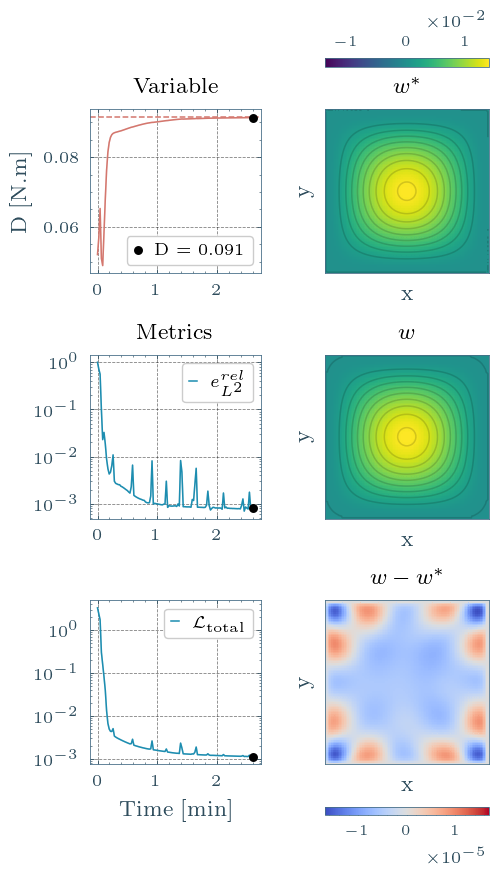

In [10]:
# Legacy-style regular 3x2 layout using plot utilities
import numpy as np
from phd.plot.plot_util import plot_field, add_colorbar, init_metrics, update_metrics, init_parameter_evolution, update_parameter_evolution

def plot_clamped_three_rows_two_cols(results, page_width):
    cfg = results['config']
    net_type = str(cfg.model.net_type)

    ref = results.get('reference', None)
    if ref is None:
        ref_interp = cp._make_reference_interpolator(cfg)
        x_grid = np.asarray(ref_interp['x_grid'])
        y_grid = np.asarray(ref_interp['y_grid'])
        w_ref = np.asarray(ref_interp['w_grid'])[:, :, 0]
    else:
        x_grid = np.asarray(ref['x_grid'])
        y_grid = np.asarray(ref['y_grid'])
        w_ref = np.asarray(ref['w_grid'])[:, :, 0]

    X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')

    field_saver = results.get('callbacks', {}).get('field_saver', None)
    has_field_history = field_saver is not None and getattr(field_saver, 'history', None)

    if results.get('model', None) is not None:
        if net_type == 'SPINN':
            X_input = [x_grid.reshape(-1, 1), y_grid.reshape(-1, 1)]
        else:
            XX, YY = np.meshgrid(x_grid, y_grid, indexing='ij')
            X_input = np.stack((XX.ravel(), YY.ravel()), axis=1)

        pred_raw = results['model'].predict(X_input)
        if isinstance(pred_raw, (tuple, list)):
            pred_raw = pred_raw[0]
        pred_raw = np.asarray(pred_raw)

        nx, ny = x_grid.size, y_grid.size
        if pred_raw.ndim == 3 and pred_raw.shape[0] == nx and pred_raw.shape[1] == ny:
            w_pred = pred_raw[:, :, 0]
        elif pred_raw.ndim == 2 and pred_raw.shape[0] == nx * ny:
            w_pred = pred_raw[:, 0].reshape(nx, ny)
        elif pred_raw.ndim == 1 and pred_raw.size == nx * ny:
            w_pred = pred_raw.reshape(nx, ny)
        else:
            w_pred = pred_raw.reshape(nx, ny)
    elif has_field_history:
        w_pred = np.asarray(field_saver.history[-1][1]['W']).reshape(x_grid.size, y_grid.size)
    else:
        raise ValueError('No model and no field history found in results; run with save_fields=True or restore a model.')

    w_res = w_pred - w_ref

    losshistory = results['losshistory']
    steps = np.asarray(losshistory.steps, dtype=float)
    loss_train = np.asarray([np.asarray(v) for v in losshistory.loss_train], dtype=float)
    pde_loss = loss_train[:, 0]
    total_loss = np.mean(loss_train, axis=1)
    l2_error = np.asarray(losshistory.metrics_test).squeeze() if len(losshistory.metrics_test) else None

    elapsed = float(results.get('runtime_metrics', {}).get('elapsed_time', 0.0))
    total_steps = max(float(steps[-1]) if len(steps) > 0 else 1.0, 1.0)
    time_min = (steps * elapsed / total_steps) / 60.0

    var_cb = results.get('callbacks', {}).get('variable_value', None)
    d_steps = np.array([])
    d_values = np.array([])
    if var_cb is not None and getattr(var_cb, 'history', None):
        d_steps = np.asarray([h[0] for h in var_cb.history], dtype=float)
        d_values = np.asarray([float(np.asarray(h[1]).reshape(-1)[0]) for h in var_cb.history], dtype=float)

    E = float(cfg.problem.material.E)
    nu = float(cfg.problem.material.nu)
    h = float(cfg.problem.material.thickness)
    D_ref = E * h**3 / (12.0 * (1.0 - nu**2))

    fig, ax = plt.subplots(3, 2, figsize=(page_width * 0.55, page_width * 0.9), dpi=200)
    fig.subplots_adjust(wspace=0.35, hspace=0.5)

    ax_var = ax[0, 0]
    ax_metric_top = ax[1, 0]
    ax_metric_bottom = ax[2, 0]
    ax_ref = ax[0, 1]
    ax_pred = ax[1, 1]
    ax_res = ax[2, 1]

    # Left column: variable and metrics
    if d_values.size > 0:
        d_time_min = (d_steps * elapsed / total_steps) / 60.0
        var_artist = init_parameter_evolution(
            ax_var,
            d_time_min,
            d_values,
            true_val=D_ref,
            label='D',
            step_type='time',
            time_unit='min',
            show_xlabel=False,
            color='C1'
        )
        update_parameter_evolution(d_time_min[-1], var_artist)
    else:
        ax_var.text(0.5, 0.5, 'No variable history available', ha='center', va='center', transform=ax_var.transAxes)
    ax_var.set_title('Variable')
    ax_var.set_ylabel('D [N.m]')
    ax_var.grid(True)

    if l2_error is not None and np.ndim(l2_error) > 0 and len(np.asarray(l2_error)) == len(time_min):
        top_metrics = {'L2 Error': np.asarray(l2_error)}
        top_select = ['L2 Error']
    else:
        top_metrics = {'PDE Loss': pde_loss}
        top_select = ['PDE Loss']
    top_artists = init_metrics(
        ax_metric_top,
        time_min,
        top_metrics,
        selected_metrics=top_select,
        step_type='time',
        time_unit='min',
        log_scale=True,
        use_title=False,
    )
    update_metrics(time_min[-1], top_artists)
    ax_metric_top.set_title('Metrics')
    ax_metric_top.set_xlabel('')
    ax_metric_top.grid(True)

    bottom_artists = init_metrics(
        ax_metric_bottom,
        time_min,
        {'PDE Loss': pde_loss, 'Total Loss': total_loss},
        selected_metrics=['Total Loss'],
        step_type='time',
        time_unit='min',
        log_scale=True,
        use_title=False,
    )
    update_metrics(time_min[-1], bottom_artists)
    ax_metric_bottom.grid(True)

    # Right column: reference, approximation, residual
    v_abs = max(float(np.nanmax(np.abs(w_ref))), float(np.nanmax(np.abs(w_pred))), 1e-12)
    ref_art = plot_field(ax_ref, X, Y, w_ref, title=r'$w^*$', cmap='viridis', vmin=-v_abs, vmax=v_abs, plot_contours=True, hide_frame=False)
    pred_art = plot_field(ax_pred, X, Y, w_pred, title=r'$w$', cmap='viridis', vmin=-v_abs, vmax=v_abs, plot_contours=True, hide_frame=False)

    add_colorbar(fig, ax_ref, ref_art['im'], location='top', shift=0.05)

    r_abs = max(float(np.nanmax(np.abs(w_res))), 1e-12)
    res_art = plot_field(ax_res, X, Y, w_res, title=r'$w - w^*$', cmap='coolwarm', vmin=-r_abs, vmax=r_abs, plot_contours=False, hide_frame=False)
    add_colorbar(fig, ax_res, res_art['im'], location='bottom', shift=0.05)

    for a in [ax_ref, ax_pred, ax_res]:
        a.set_xlabel('x')
        a.set_ylabel('y')
        a.set_aspect('equal', adjustable='box')

    return fig

fig = plot_clamped_three_rows_two_cols(results_disp, page_width=page_width)
plt.show()

if save_fig:
    fig.savefig(PDF_DIR / f'{disp_run_name}.pdf', bbox_inches='tight')
    fig.savefig(IMAGE_DIR / f'{disp_run_name}.png', bbox_inches='tight', dpi=300)

In [6]:
# Save inverse identification table (Reference vs identified D)
import numpy as np

def to_tex_sci(value: float) -> str:
    if not np.isfinite(value):
        return ''
    if value == 0:
        return '$0$'
    exp = int(np.floor(np.log10(abs(value))))
    mant = value / (10 ** exp)
    return rf'${mant:.3f}\\cdot 10^{{{exp}}}$'

def extract_identified_D(results) -> float:
    var_cb = results.get('callbacks', {}).get('variable_value', None)
    if var_cb is None or not getattr(var_cb, 'history', None):
        return np.nan
    last_entry = var_cb.history[-1]
    val = last_entry[1] if isinstance(last_entry, (list, tuple)) and len(last_entry) > 1 else last_entry
    return float(np.asarray(val).reshape(-1)[0])

cfg_res = results_disp['config']
E = float(cfg_res.problem.material.E)
nu = float(cfg_res.problem.material.nu)
h = float(cfg_res.problem.material.thickness)
D_ref = E * h**3 / (12.0 * (1.0 - nu**2))

D_est = extract_identified_D(results_disp)
D_err_pct = np.nan if not np.isfinite(D_est) else 100.0 * abs(D_est - D_ref) / abs(D_ref)

model_name = str(cfg_res.model.net_type).upper()
df_results = pd.DataFrame(
    [
        {'': 'Reference', 'D [N.m]': D_ref, 'D - Error(%)': np.nan},
        {'': model_name, 'D [N.m]': D_est, 'D - Error(%)': D_err_pct},
    ]
)

display(df_results)

save_table = True
if save_table:
    out_path = TABLE_DIR / 'clamped_plate_inverse_D_results.tex'
    formatters = {
        'D [N.m]': to_tex_sci,
        'D - Error(%)': lambda x: '' if pd.isna(x) else f'{x:.2f}',
    }
    save_df_to_latex(
        df_results,
        out_path,
        formatters=formatters,
        index=False,
        escape=False,
        na_rep='',
        column_format='lcc',
    )
    print(f'Saved table: {out_path}')

,,D [N.m],D - Error(%)
0,Reference,0.091575,NaN
1,SPINN,0.091338,0.258867


Saved LaTeX table to /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/03_clamped_plate/tables/clamped_plate_inverse_D_results.tex
Saved table: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/03_clamped_plate/tables/clamped_plate_inverse_D_results.tex
